In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [2]:
train_df = pd.read_csv("Training_set.csv")
test_df = pd.read_csv("Testing_set.csv")

In [3]:
train_df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [4]:
train_df.shape

(6499, 2)

In [5]:
test_df.shape

(2786, 1)

In [6]:
train_df.isnull().sum()

filename    0
label       0
dtype: int64

In [7]:
test_df.isnull().sum()

filename    0
dtype: int64

In [8]:
print(train_df["label"].nunique())

75


In [9]:
train_df["label"].unique()

array(['SOUTHERN DOGFACE', 'ADONIS', 'BROWN SIPROETA', 'MONARCH',
       'GREEN CELLED CATTLEHEART', 'CAIRNS BIRDWING',
       'EASTERN DAPPLE WHITE', 'RED POSTMAN', 'MANGROVE SKIPPER',
       'BLACK HAIRSTREAK', 'CABBAGE WHITE', 'RED ADMIRAL', 'PAINTED LADY',
       'PAPER KITE', 'SOOTYWING', 'PINE WHITE', 'PEACOCK',
       'CHECQUERED SKIPPER', 'JULIA', 'COMMON WOOD-NYMPH', 'BLUE MORPHO',
       'CLOUDED SULPHUR', 'STRAITED QUEEN', 'ORANGE OAKLEAF',
       'PURPLISH COPPER', 'ATALA', 'IPHICLUS SISTER', 'DANAID EGGFLY',
       'LARGE MARBLE', 'PIPEVINE SWALLOW', 'BLUE SPOTTED CROW',
       'RED CRACKER', 'QUESTION MARK', 'CRIMSON PATCH', 'BANDED PEACOCK',
       'SCARCE SWALLOW', 'COPPER TAIL', 'GREAT JAY', 'INDRA SWALLOW',
       'VICEROY', 'MALACHITE', 'APPOLLO', 'TWO BARRED FLASHER',
       'MOURNING CLOAK', 'TROPICAL LEAFWING', 'POPINJAY', 'ORANGE TIP',
       'GOLD BANDED', 'BECKERS WHITE', 'RED SPOTTED PURPLE',
       'MILBERTS TORTOISESHELL', 'SILVER SPOT SKIPPER', 'AMERICAN SN

In [10]:
encoder = LabelEncoder()

train_df["label_encoded"] = encoder.fit_transform(train_df["label"])

In [11]:
train_df["filepath"] = "train/" + train_df["filename"]

test_df["filepath"] = "test/" + test_df["filename"]

In [12]:
train_df.head()

,filename,label,label_encoded,filepath
0,Image_1.jpg,SOUTHERN DOGFACE,66,train/Image_1.jpg
1,Image_2.jpg,ADONIS,0,train/Image_2.jpg
2,Image_3.jpg,BROWN SIPROETA,12,train/Image_3.jpg
3,Image_4.jpg,MONARCH,44,train/Image_4.jpg
4,Image_5.jpg,GREEN CELLED CATTLEHEART,33,train/Image_5.jpg


In [13]:
IMG_SIZE = 224

def load_images(paths):
    
    images = []

    for path in paths:

        img = cv2.imread(path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0

        images.append(img)

    return np.array(images)

In [14]:
X = load_images(train_df["filepath"])

y = train_df["label_encoded"]

In [15]:
print(X.shape)
print(y.shape)

(6499, 224, 224, 3)
(6499,)


In [16]:
y = to_categorical(y)

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("Train :", X_train.shape)

print("Validation :", X_val.shape)

Train : (5199, 224, 224, 3)
Validation : (1300, 224, 224, 3)


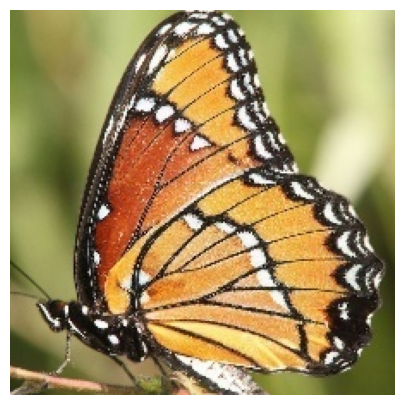

In [19]:
plt.figure(figsize=(5,5))
plt.imshow(X_train[0])
plt.axis("off")
plt.show()

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [21]:
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [22]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="",
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 5200 validated image filenames belonging to 75 classes.


In [23]:
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="",
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 1299 validated image filenames belonging to 75 classes.


In [24]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [25]:
base_model.trainable = False

In [26]:
NUM_CLASSES = len(train_df["label"].unique())

print(NUM_CLASSES)

75


In [27]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [28]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,354,059 (8.98 MB)

 Trainable params: 96,075 (375.29 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
print(model.input_shape)
print(model.output_shape)

(None, 224, 224, 3)
(None, 75)


In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [32]:
checkpoint = ModelCheckpoint(
    "best_butterfly_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [33]:
loss, accuracy = model.evaluate(valid_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 31s 687ms/step - accuracy: 0.0177 - loss: 4.7503
Validation Loss : 4.750338077545166
Validation Accuracy : 0.017705928534269333


In [34]:
model.save("butterfly_final_model.keras")

In [35]:
from tensorflow.keras.models import load_model

model = load_model("butterfly_final_model.keras")

e:\New\envs\ml_env\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Validation Prediction

In [36]:
pred = model.predict(valid_generator)

pred_class = np.argmax(pred, axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 29s 694ms/step


True Label


In [37]:
true_class = valid_generator.classes

Confusion Matrix

In [38]:
cm = confusion_matrix(true_class, pred_class)

print(cm)

[[0 0 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [0 0 1 ... 1 0 2]
 ...
 [0 0 0 ... 0 0 0]
 [1 0 1 ... 0 0 1]
 [7 0 1 ... 0 0 0]]


Classification Report

In [39]:
labels = list(valid_generator.class_indices.keys())

print(
    classification_report(
        true_class,
        pred_class,
        target_names=labels
    )
)

                           precision    recall  f1-score   support

                   ADONIS       0.00      0.00      0.00        19
AFRICAN GIANT SWALLOWTAIL       0.00      0.00      0.00        17
           AMERICAN SNOOT       0.03      0.06      0.04        16
                    AN 88       0.00      0.00      0.00        17
                  APPOLLO       0.00      0.00      0.00        14
                    ATALA       0.00      0.00      0.00        23
 BANDED ORANGE HELICONIAN       0.14      0.47      0.22        19
           BANDED PEACOCK       0.00      0.00      0.00        16
            BECKERS WHITE       0.00      0.00      0.00        16
         BLACK HAIRSTREAK       0.00      0.00      0.00        27
              BLUE MORPHO       0.00      0.00      0.00        10
        BLUE SPOTTED CROW       0.00      0.00      0.00        16
           BROWN SIPROETA       0.00      0.00      0.00        26
            CABBAGE WHITE       0.00      0.00      0.00     

e:\New\envs\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\New\envs\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\New\envs\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Test Generator

In [40]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="",
    x_col="filepath",
    y_col=None,
    target_size=(224,224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

Found 2786 validated image filenames.


Predict Test Images

In [41]:
prediction = model.predict(test_generator)

88/88 ━━━━━━━━━━━━━━━━━━━━ 71s 795ms/step


Convert Probability to Class

In [42]:
predicted_index = np.argmax(prediction, axis=1)

Convert Index to Label

In [43]:
label_map = {v:k for k,v in train_generator.class_indices.items()}

predicted_label = [
    label_map[i]
    for i in predicted_index
]

Submission File

In [44]:
submission = pd.DataFrame({
    "filename": test_df["filename"],
    "label": predicted_label
})

Save CSV

In [45]:
submission.to_csv(
    "submission.csv",
    index=False
)

Check Submission

In [46]:
submission.head()

,filename,label
0,Image_1.jpg,PEACOCK
1,Image_2.jpg,ORCHARD SWALLOW
2,Image_3.jpg,PEACOCK
3,Image_4.jpg,ORCHARD SWALLOW
4,Image_5.jpg,LARGE MARBLE


Single Image Prediction

In [47]:
image_path = "test/Image_10.jpg"

img = cv2.imread(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img,(224,224))

img = img/255.0

img = np.expand_dims(img,axis=0)

prediction = model.predict(img)

index = np.argmax(prediction)

print(label_map[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step
WOOD SATYR


Best Model Load5

MobileNetV2-এর কিছু Layer Unfreeze

In [48]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False



create model


In [49]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

NUM_CLASSES = len(train_df["label"].unique())

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

আবার Compile

In [50]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Fine Tune Training

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 157s 942ms/step - accuracy: 0.0148 - loss: 4.9146 - val_accuracy: 0.0108 - val_loss: 4.5907
Epoch 2/10
140/163 ━━━━━━━━━━━━━━━━━━━━ 17s 782ms/step - accuracy: 0.0146 - loss: 4.7718

Final Accuracy

In [ ]:
loss, accuracy = model.evaluate(valid_generator)

print("Final Accuracy :", accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 28s 673ms/step - accuracy: 0.0916 - loss: 3.8846
Final Accuracy : 0.091608926653862


Confusion Matrix Plot

41/41 ━━━━━━━━━━━━━━━━━━━━ 29s 688ms/step


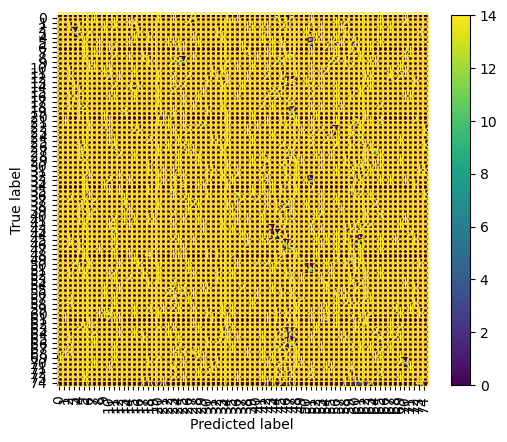

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

pred = model.predict(valid_generator)
pred_class = pred.argmax(axis=1)

ConfusionMatrixDisplay.from_predictions(
    valid_generator.classes,
    pred_class,
    xticks_rotation=90
)

plt.show()

Save Final Model

In [ ]:
model.save("Butterfly_Final.keras")

Save Label Mapping

In [ ]:
import json

with open("label_map.json","w") as f:
    json.dump(train_generator.class_indices,f)

Load Label Mapping

In [ ]:
with open("label_map.json") as f:
    label_map = json.load(f)

Predict Any Image

In [ ]:
import cv2
import numpy as np

image_path = "test/Image_50.jpg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img,(224,224))

img = img/255.0

img = np.expand_dims(img,axis=0)

prediction = model.predict(img)

index = np.argmax(prediction)

reverse = {v:k for k,v in label_map.items()}

print(reverse[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
EASTERN PINE ELFIN


In [ ]:
# MobileNetV2 Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
base_model.trainable=False
NUM_CLASSES=len(train_df['label'].unique())
x=GlobalAveragePooling2D()(base_model.output)
x=Dropout(0.3)(x)
outputs=Dense(NUM_CLASSES,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=outputs)
model.compile(optimizer=Adam(1e-4),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,354,059 (8.98 MB)

 Trainable params: 96,075 (375.29 KB)

 Non-trainable params: 2,257,984 (8.61 MB)